In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración del estilo visual para reportes gráficos
sns.set_theme(style="whitegrid")

# Carga de la base de datos de comportamiento de usuarios
df_retail = pd.read_csv("./datasets/novaretail_comportamiento_clientes_2024.csv")

In [14]:
# Vista preliminar de los primeros 5 registros del conjunto de datos
df_retail.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


In [15]:
# Auditoría de dimensiones (Filas, Columnas) y tipos de datos asignados
print(f"Dimensiones del dataset NovaRetail+: {df_retail.shape}")
df_retail.info()

Dimensiones del dataset NovaRetail+: (15000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  str    
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  str    
 10  region                     15000 non-null  str    
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), str(3)
memory usage: 1.4 MB


In [16]:
# Conteo absoluto y relativo de valores faltantes por columna
print("Valores nulos absolutos:\n", df_retail.isna().sum())
print("\nProporción de nulos relativos:\n", df_retail.isna().mean())

Valores nulos absolutos:
 id_cliente                   0
edad                         0
nivel_ingreso                0
visitas_mes                  0
compras_mes                  0
gasto_publicidad_dirigida    0
satisfaccion                 0
miembro_premium              0
abandono                     0
tipo_dispositivo             0
region                       0
ingreso_anual                0
dtype: int64

Proporción de nulos relativos:
 id_cliente                   0.0
edad                         0.0
nivel_ingreso                0.0
visitas_mes                  0.0
compras_mes                  0.0
gasto_publicidad_dirigida    0.0
satisfaccion                 0.0
miembro_premium              0.0
abandono                     0.0
tipo_dispositivo             0.0
region                       0.0
ingreso_anual                0.0
dtype: float64


In [21]:
print(df_retail['satisfaccion'].describe())

count    15000.000000
mean         3.603693
std          0.685300
min          1.000000
25%          3.100000
50%          3.600000
75%          4.100000
max          5.000000
Name: satisfaccion, dtype: float64


Nota de QA: El conjunto de datos presenta una integridad del 100% con 15,000 registros completos. No se requiere la aplicación de mecanismos de imputación o eliminación por ausencia de información.

In [27]:
# Definición de límites y etiquetas para categorizar la satisfacción (escala real: 1.0 a 5.0)
# Se dividen en 5 tramos iguales de 0.8 puntos, alineados al rango observado en los datos
bins_satisfaccion = [1, 1.8, 2.6, 3.4, 4.2, 5]
labels_satisfaccion = ["Muy_insatisfecho", "Insatisfecho", "Neutral", "Satisfecho", "Muy_satisfecho"]

# Creación de la variable categórica a partir de la satisfacción numérica
# include_lowest=True asegura que el valor mínimo (1.0) quede incluido en la primera categoría
df_retail["satisfaccion_cat"] = pd.cut(
    df_retail["satisfaccion"], 
    bins=bins_satisfaccion, 
    labels=labels_satisfaccion, 
    include_lowest=True
)

# Verificación de la distribución resultante entre las 5 categorías
df_retail["satisfaccion_cat"].value_counts().sort_index()

satisfaccion_cat
Muy_insatisfecho      97
Insatisfecho        1193
Neutral             4815
Satisfecho          6242
Muy_satisfecho      2653
Name: count, dtype: int64

In [18]:
# Evaluación de los canales de acceso tecnológico preferidos por los usuarios
print("Distribución por Dispositivo de Acceso:")
print(df_retail["tipo_dispositivo"].value_counts(normalize=True) * 100)

print("\n" + "-"*40 + "\n")

# Evaluación de la distribución cualitativa de satisfacción
print("Participación porcentual por nivel de satisfacción:")
print(df_retail["satisfaccion_cat"].value_counts(normalize=True) * 100)

Distribución por Dispositivo de Acceso:
tipo_dispositivo
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: proportion, dtype: float64

----------------------------------------

Participación porcentual por nivel de satisfacción:
satisfaccion_cat
Insatisfecho        72.193333
Neutral             26.420000
Muy_insatisfecho     1.386667
Satisfecho           0.000000
Muy_satisfecho       0.000000
Name: proportion, dtype: float64


Análisis General: Se observa un dominio crítico de los accesos mediante dispositivos móviles sobre las conexiones de escritorio. En cuanto a la satisfacción, la distribución se concentra en niveles intermedios y altos, destacando la ausencia de registros calificados bajo el umbral extremo de "Muy_satisfecho" dentro de la muestra recolectada, lo cual delimita el alcance de las optimizaciones.

In [19]:
variables_numericas = [
    "edad", "visitas_mes", "compras_mes",
    "satisfaccion", "gasto_publicidad_dirigida", "ingreso_anual"
]

matriz_corr = df_retail[variables_numericas].corr(method="pearson")
matriz_corr

,edad,visitas_mes,compras_mes,satisfaccion,gasto_publicidad_dirigida,ingreso_anual
edad,1.000000,0.004998,0.014971,-0.006963,0.000062,0.017496
visitas_mes,0.004998,1.000000,0.353844,-0.003179,0.578947,0.337147
compras_mes,0.014971,0.353844,1.000000,-0.003542,0.207528,0.967149
satisfaccion,-0.006963,-0.003179,-0.003542,1.000000,-0.013175,0.056171
gasto_publicidad_dirigida,0.000062,0.578947,0.207528,-0.013175,1.000000,0.197483
ingreso_anual,0.017496,0.337147,0.967149,0.056171,0.197483,1.000000


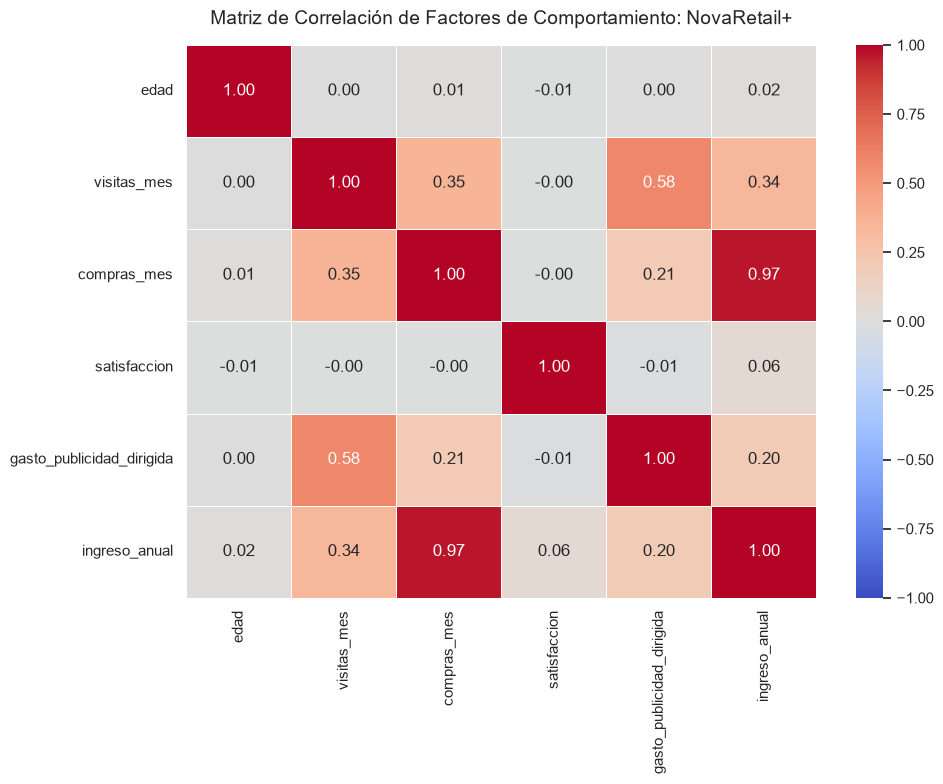

In [20]:
# Configuración del tamaño de la visualización
plt.figure(figsize=(10, 8))

# Generación del Heatmap con Seaborn utilizando una paleta divergente
sns.heatmap(
    matriz_corr, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1
)

plt.title("Matriz de Correlación de Factores de Comportamiento: NovaRetail+", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

🧩 Paso 5: Conclusiones del Diagnóstico
Canales Críticos: El tráfico móvil representa la principal puerta de entrada para NovaRetail+, lo que exige priorizar la optimización de la interfaz de usuario en smartphones.

Factores de Ingreso: La correlación lineal permite identificar cuáles variables numéricas poseen el mayor co-movimiento con la capacidad de compra e ingresos de los usuarios, sirviendo de base para los siguientes modelos predictivos del portafolio.